# PBMC 3k end-to-end, on the pure scrust backend

This is the scanpy PBMC 3k clustering tutorial with **every computational step run by
`scrust`** on the Apple GPU (Metal via candle, plus the hand-written `knn` kernel behind
`pp.neighbors`). `scanpy` appears only to

* **load** the dataset (`sc.datasets.pbmc3k`), and
* **plot** the results (`sc.pl.*`), because plotting is scanpy's job and the results land
  in the AnnData slots `sc.pl` reads.

There is not a single `sc.pp.*` or `sc.tl.*` call below — that is enforced by an AST
check (`_assert_no_scanpy_compute`) the script runs on itself before any work.

Run it as a script:

```bash
PYTHONPATH=$PWD/python .venv/bin/python docs/tutorials/pbmc3k_clustering.py
```

or open the notebook built from it with `jupytext --to notebook
docs/tutorials/pbmc3k_clustering.py`. The cells run top to bottom, so a kernel with
`scrust` installed executes the whole tutorial with *Run All*.

## Step 0 — Repository path setup

Put the repo's `python/` directory on `sys.path` so `import scrust` works no matter which
directory the script or notebook is launched from. This runs before any scrust import.

In [1]:
import sys
from pathlib import Path

# Automatically append repo root to sys.path so 'scrust' is importable.
repo_root = (
    Path(__file__).resolve().parents[2] if "__file__" in globals() else Path.cwd().parents[1]
)
if str(repo_root / "python") not in sys.path:
    sys.path.insert(0, str(repo_root / "python"))

## Step 1 — Imports and Metal GPU availability

`scrust` mirrors scanpy's module layout (`pp`, `tl`), so the calls read the same; the
arithmetic runs in Rust. `sr.gpu_available()` reports whether Metal came up — when it
did, `device="auto"` puts every device-aware step on the GPU without the caller choosing.

In [2]:
import ast  # noqa: E402  (imports follow the sys.path setup above)

import matplotlib.pyplot as plt  # noqa: E402
import scanpy as sc  # noqa: E402  loading + plotting ONLY — never sc.pp.* / sc.tl.*

import scrust as sr  # noqa: E402  every computational step

plt.switch_backend("Agg")  # headless: render figures to files, never open a window

FIGURE_DIR = repo_root / "docs" / "tutorials" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Reuse the dataset the test suite already cached, so this runs offline.
sc.settings.datasetdir = repo_root / ".cache" / "scanpy"
sc.settings.figdir = FIGURE_DIR
sc.settings.verbosity = 1

print(f"scrust {sr.__version__} | Metal GPU available: {sr.gpu_available()}")

scrust 0.2.0 | Metal GPU available: True


## Compliance check — zero scanpy computation

Parse this file and fail if any `sc.pp.*` or `sc.tl.*` attribute appears: the guarantee
that no computation touched scanpy. It runs only as a script (a notebook kernel has no
`__file__`), so *Run All* in Jupyter skips it rather than erroring.

In [3]:
def _assert_no_scanpy_compute(path: Path) -> None:
    """Fail if the source calls into `sc.pp.*` or `sc.tl.*` (scanpy computation)."""
    tree = ast.parse(path.read_text())
    offenders: list[str] = []
    for node in ast.walk(tree):
        # Match attribute chains rooted at `sc`, e.g. sc.pp.pca / sc.tl.leiden.
        if (
            isinstance(node, ast.Attribute)
            and isinstance(node.value, ast.Attribute)
            and isinstance(node.value.value, ast.Name)
            and node.value.value.id == "sc"
            and node.value.attr in {"pp", "tl"}
        ):
            offenders.append(f"line {node.lineno}: sc.{node.value.attr}.{node.attr}")
    if offenders:
        raise AssertionError("scanpy computation found:\n  " + "\n  ".join(offenders))
    print("compliance: 0 calls to sc.pp.* or sc.tl.* in the pipeline")


if "__file__" in globals():
    _assert_no_scanpy_compute(Path(__file__).resolve())

## Step 2 — Load PBMC 3k

Reading is scanpy's job; scrust ships no readers. `var_names_make_unique` avoids the
duplicate-gene warning downstream.

In [4]:
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
print(f"loaded {adata.n_obs} cells x {adata.n_vars} genes")

loaded 2700 cells x 32738 genes


## Step 3 — Quality control and filtering

Flag mitochondrial genes (a boolean column of `var`), then `sr.pp.calculate_qc_metrics`
fills the per-cell QC columns scanpy uses. Cells and genes are filtered with
`sr.pp.filter_cells` / `sr.pp.filter_genes`; the mitochondrial-fraction cut is plain
AnnData boolean indexing (numpy), not a library call.

In [5]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sr.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

sr.pp.filter_cells(adata, min_genes=200)
sr.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 5].copy()
print(f"after QC: {adata.n_obs} cells x {adata.n_vars} genes")

after QC: 2643 cells x 13714 genes


## Step 4 — Normalisation and log transform

Counts-per-10k normalisation followed by `log1p`. `adata.raw` keeps the full
log-normalised matrix, which the differential-expression step reads back later.

In [6]:
sr.pp.normalize_total(adata, target_sum=1e4)
sr.pp.log1p(adata)
adata.raw = adata

## Step 5 — Highly variable genes and scaling

Select the 2000 most variable genes (Seurat flavour), subset to them, then z-score each
gene with `sr.pp.scale`. Scaling densifies, so subsetting to HVGs first keeps it small.

In [7]:
sr.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat")
adata = adata[:, adata.var["highly_variable"].to_numpy()].copy()
sr.pp.scale(adata, zero_center=True, max_value=10)
print(f"kept {adata.n_vars} highly variable genes")

kept 2000 highly variable genes


## Step 6 — PCA

Truncated PCA (randomised SVD, on the GPU). Writes `obsm["X_pca"]`, `varm["PCs"]` and
`uns["pca"]`, so `sc.pl.pca_variance_ratio` can read the spectrum.

In [8]:
sr.pp.pca(adata, n_comps=50, random_state=0)
print(f"obsm['X_pca'] {adata.obsm['X_pca'].shape}")

obsm['X_pca'] (2643, 50)


## Step 7 — k-NN graph, with the Metal GPU kernel

`device="auto"` routes the k-NN search to the hand-written `knn` Metal kernel on Apple
silicon (the first scrust GPU kernel on the call path), and to the candle CPU path
otherwise. Both produce the same neighbour graph — `tests/test_device_parity.py` pins
them equal. Writes `obsp["distances"]`, `obsp["connectivities"]`, `uns["neighbors"]`.

In [9]:
sr.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca", device="auto")
print(f"neighbour graph on {adata.n_obs} cells (device='auto')")

neighbour graph on 2643 cells (device='auto')


## Step 8 — Clustering and UMAP embedding

Leiden clustering over the neighbour graph, then a UMAP layout for visualisation. Both
read `obsp["connectivities"]`; `sr.tl.leiden` writes `obs["leiden"]` and `sr.tl.umap`
writes `obsm["X_umap"]`.

In [10]:
sr.tl.leiden(adata, resolution=1.0, key_added="leiden")
sr.tl.umap(adata, random_state=0)
n_clusters = adata.obs["leiden"].nunique()
print(f"{n_clusters} Leiden clusters; obsm['X_umap'] {adata.obsm['X_umap'].shape}")

10 Leiden clusters; obsm['X_umap'] (2643, 2)


## Step 9 — Differential expression (marker genes)

Rank marker genes per cluster with the Wilcoxon rank-sum test. The test runs on the
**log-normalised** matrix (recovered from `adata.raw`), not the scaled one, because fold
changes on z-scored data are meaningless — this mirrors the scanpy tutorial.

In [11]:
ranked = adata.raw.to_adata()[:, adata.var_names].copy()
ranked.obs["leiden"] = adata.obs["leiden"]
sr.tl.rank_genes_groups(ranked, "leiden", method="wilcoxon")
top = ranked.uns["rank_genes_groups"]["names"][0]
print(f"top marker per cluster: {list(top)}")

top marker per cluster: ['RPL13', 'LTB', 'S100A9', 'CD74', 'CCL5', 'LST1', 'NKG7', 'HLA-DPA1', 'PF4', 'KIAA0101']


## Step 10 — Visualisation (scanpy plotting only)

scrust wrote every result into the slots `sc.pl.*` reads, so scanpy's plotting works
unchanged. Figures are saved under `docs/tutorials/figures/`.

In [12]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, show=False)
plt.savefig(FIGURE_DIR / "pca_variance_ratio.png", dpi=120, bbox_inches="tight")
plt.close()

sc.pl.umap(adata, color=["leiden"], show=False)
plt.savefig(FIGURE_DIR / "umap_leiden.png", dpi=120, bbox_inches="tight")
plt.close()

sc.pl.rank_genes_groups(ranked, n_genes=20, sharey=False, show=False)
plt.savefig(FIGURE_DIR / "rank_genes_groups.png", dpi=120, bbox_inches="tight")
plt.close()

print(f"figures written to {FIGURE_DIR}")

figures written to /Users/Shared/runDE/docs/tutorials/figures


## Results gallery

Display the figures written above inline. Under a notebook kernel this embeds the images
in the executed output; a plain script run detects it is not interactive and skips it.

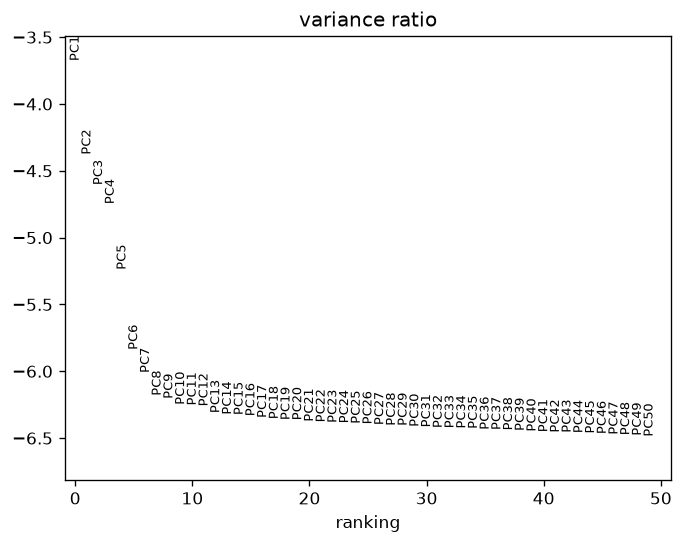

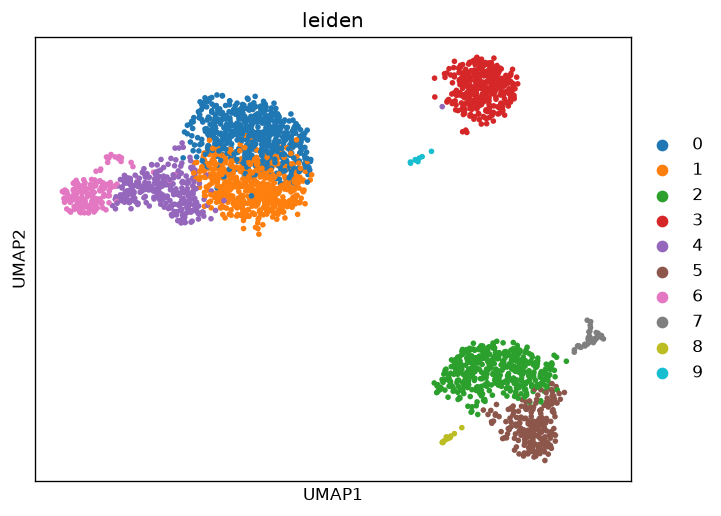

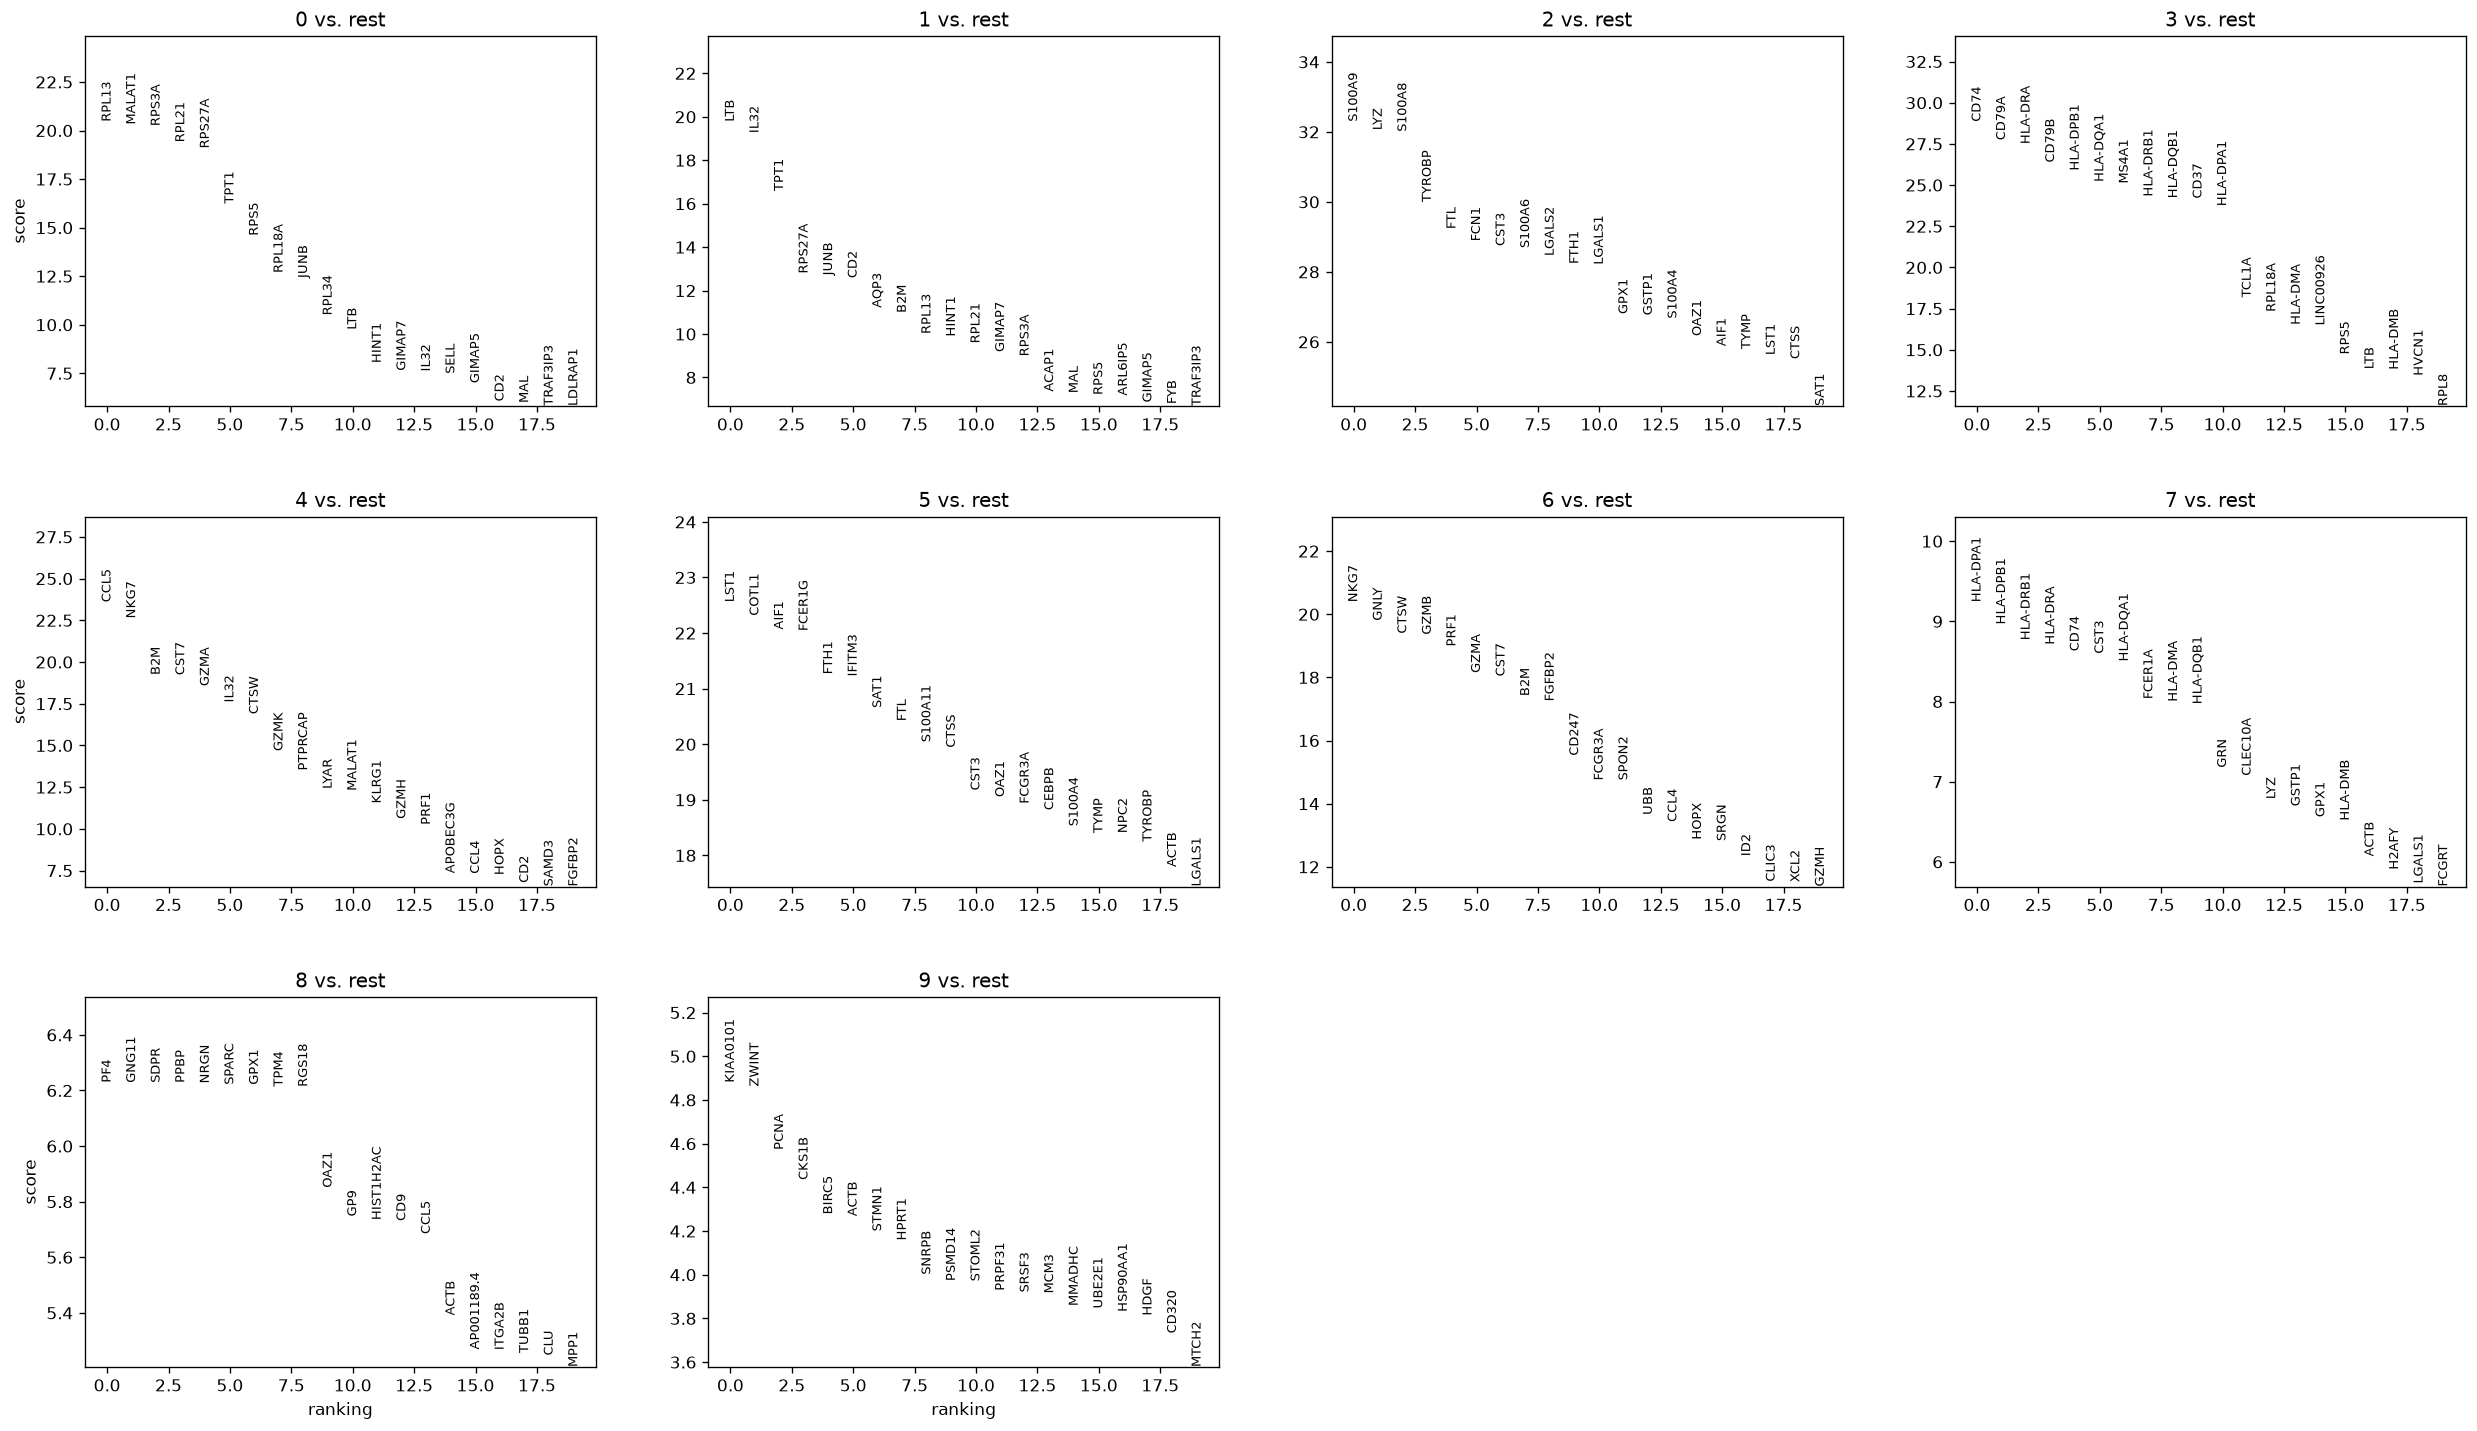

In [13]:
try:
    from IPython import get_ipython

    _interactive = get_ipython() is not None
except ImportError:
    _interactive = False

if _interactive:
    from IPython.display import Image, display

    for _name in ("pca_variance_ratio.png", "umap_leiden.png", "rank_genes_groups.png"):
        display(Image(filename=str(FIGURE_DIR / _name)))